# 05 — Heat-Pollution Index (HPI) Extension

**Question.** Is pollen concentration alone a sufficient indicator of allergic risk, or does a composite index combining **heat and air pollution (O₃, NO₂)** better explain its variations? And does the comparison of summers 2022 vs 2024 across four climatically contrasted French cities constitute a measurable proxy for a structural warming trend?

**Motivation.** Notebooks 01–04 have established a rigorous univariate forecasting pipeline for six pollen species across Paris, Marseille, Strasbourg, Bordeaux. Three gaps motivate this extension:

1. **Biological synergy.** Epidemiology literature (Sousa-Silva et al., 2021; D'Amato et al., 2020) shows that O₃ and NO₂ degrade pollen protein coats, amplifying IgE-mediated response. A pollen-only model ignores this multiplicative effect.
2. **Climatic signal.** Grid-search models (NB03) and CV comparisons (NB04) treat weather as stationary. Comparing paired summers (JJA 2022 vs JJA 2024) tests whether inter-annual drift is already detectable on a 3-year window.
3. **Unused covariates.** Lessons from NB02/03 (`tasks/lessons.md`, 2026-03-26) flagged (i) GDD computed but never used as exogenous, (ii) ARIMAX forced to lag-0 weather despite lagged cross-correlation evidence, (iii) Gaussian CIs despite non-normal residuals. This notebook remediates all three.

**Pipeline.**

```
                OPEN-METEO AIR QUALITY API
                 ozone  NO₂  PM₂.₅  (daily)
                           │
                           ▼
              merge on (date, city) with
          pollen_weather_merged.csv  (NB01)
                           │
                           ▼
             ┌──── HPI = mean(z_T, z_O₃, z_NO₂) ────┐
             ▼                                      ▼
        EDA: Spearman × lags,                 Summer comparison
        VIF, cross-city heatmap              JJA 2022 vs JJA 2024
                           │
                           ▼
            ARIMAX:   M1 Weather only
                      M2 HPI only
                      M3 HPI + Weather + GDD
                           │
                           ▼
            Expanding-window CV on 2022–2023
            Final evaluation on 2024 test
            Friedman + Nemenyi post-hoc
```

**Composite index — mathematical definition.**

For city $c$ and day $t$, the Heat-Pollution Index is defined as the arithmetic mean of city-wise standardised scores:

$$\text{HPI}_{c,t} \;=\; \frac{1}{3}\left( \underbrace{\frac{T^{\max}_{c,t} - \mu^T_c}{\sigma^T_c}}_{z_T}
+ \underbrace{\frac{O_{3,c,t} - \mu^{O_3}_c}{\sigma^{O_3}_c}}_{z_{O_3}}
+ \underbrace{\frac{\text{NO}_{2,c,t} - \mu^{NO_2}_c}{\sigma^{NO_2}_c}}_{z_{NO_2}} \right)$$

where $\mu^\bullet_c, \sigma^\bullet_c$ are the mean and standard deviation of each variable computed **within city $c$**. Standardising per-city (rather than pooling) preserves inter-city climate/pollution contrasts: HPI = 0 means *"a typical day for this city"* rather than *"a typical day averaged over France"*. Each of the three components carries equal weight $1/3$, a neutral default avoiding arbitrary weighting; a sensitivity ablation (weighted variant and PM₂.₅ inclusion) is performed in §2.

**Conventions.** Same as NB01–04: seeds fixed to 42, relative paths, self-contained. All figures exported to `figures/` with prefix `05_`.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import openmeteo_requests
import requests_cache
from retry_requests import retry

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import pmdarima as pm

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Unified plotting style (aligned with NB01–04) ────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white", "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.framealpha": 0.9, "legend.edgecolor": "0.8", "legend.fontsize": 9,
})

CITY_COLORS = {"Paris": "#4C72B0", "Marseille": "#DD8452", "Strasbourg": "#55A868", "Bordeaux": "#C44E52"}
SPECIES_COLORS = {
    "grass_pollen": "#55A868", "birch_pollen": "#8C564B", "olive_pollen": "#E5AE38",
    "alder_pollen": "#64B5CD", "mugwort_pollen": "#8172B3", "ragweed_pollen": "#DA8BC3",
}
YEAR_COLORS = {2022: "#4C72B0", 2023: "#DD8452", 2024: "#55A868"}

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_RAW = os.path.join("..", "Data", "raw")
DATA_PROC = os.path.join("..", "Data", "processed")
FIG_DIR = os.path.join("..", "figures")
os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Setup complete.")


Setup complete.


## 1 — Air Quality Data Collection

The Open-Meteo **Air Quality API** (CAMS reanalysis, ~11 km grid over Europe) provides hourly concentrations of atmospheric pollutants. We collect three variables that enter the HPI construction:

| Variable | Unit | Role in HPI |
|:---|:---|:---|
| `ozone` (O₃) | µg/m³ | Photo-oxidant: oxidises the pollen grain protein coat, increasing IgE binding and allergenicity |
| `nitrogen_dioxide` (NO₂) | µg/m³ | Urban traffic marker: increases airway epithelial permeability to allergens |
| `pm2_5` | µg/m³ | Fine particle carrier for pollen sub-fragments (<5 µm); retained for robustness ablation only |

**Pipeline** mirrors the pollen collection of [NB01 §1](01_data_collection.ipynb): hourly fetch per city → resample to daily **mean** in `Europe/Paris` tz → concat → merge on `(date, city)` with the existing processed dataset.

**Why Open-Meteo and not ATMO France?** ATMO France publishes at regional/EPCI granularity, not city level. Open-Meteo's 11 km reanalysis grid resolves each of the four study cities directly, uses the same endpoint already integrated in NB01, and covers the full 2022-01-01 → 2024-12-31 window.

In [2]:
# ── Configuration (must match NB01 for consistent grid cells) ───────────────
CITIES = {
    "Paris":      {"lat": 48.8566, "lon": 2.3522,  "climate": "Oceanic/Continental"},
    "Marseille":  {"lat": 43.2965, "lon": 5.3698,  "climate": "Mediterranean"},
    "Strasbourg": {"lat": 48.5734, "lon": 7.7521,  "climate": "Continental"},
    "Bordeaux":   {"lat": 44.8378, "lon": -0.5792, "climate": "Oceanic"},
}
START_DATE = "2022-01-01"
END_DATE   = "2024-12-31"
AQ_VARS = ["ozone", "nitrogen_dioxide", "pm2_5"]

# Open-Meteo client (cached + retry) — reuses the existing sqlite cache if present
cache_session = requests_cache.CachedSession(os.path.join(DATA_RAW, ".cache"), expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
om = openmeteo_requests.Client(session=retry_session)
print("Open-Meteo client ready.")

Open-Meteo client ready.


In [3]:
# ── Hourly AQ fetch → daily mean, or load cached raw file ───────────────────
def fetch_air_quality(city_name, lat, lon):
    """Fetch hourly O3/NO2/PM2.5 from Open-Meteo and resample to daily mean."""
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat, "longitude": lon,
        "hourly": AQ_VARS,
        "start_date": START_DATE, "end_date": END_DATE,
        "timezone": "Europe/Paris",
    }
    responses = om.weather_api(url, params=params)
    hourly = responses[0].Hourly()
    data = {
        "datetime": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        )
    }
    for i, var in enumerate(AQ_VARS):
        data[var] = hourly.Variables(i).ValuesAsNumpy()
    hourly_df = pd.DataFrame(data)
    hourly_df["datetime"] = hourly_df["datetime"].dt.tz_convert("Europe/Paris")

    daily_df = hourly_df.set_index("datetime").resample("D").mean()
    daily_df.index = daily_df.index.date
    daily_df.index.name = "date"
    daily_df["city"] = city_name
    return daily_df

# Reuse the cached raw AQ file when available. This keeps the notebook runnable
# offline after NB01/NB05 has fetched the data once.
aq_path = os.path.join(DATA_RAW, "aq_raw.csv")
if os.path.exists(aq_path):
    aq_raw = pd.read_csv(aq_path, parse_dates=["date"])
    print(f"Loaded cached AQ raw file: {aq_path} — shape={aq_raw.shape}")
else:
    aq_frames = []
    for city, info in CITIES.items():
        print(f"  fetching air quality — {city}...")
        aq_frames.append(fetch_air_quality(city, info["lat"], info["lon"]))
    aq_raw = pd.concat(aq_frames).reset_index()
    aq_raw["date"] = pd.to_datetime(aq_raw["date"])
    aq_raw.to_csv(aq_path, index=False)
    print(f"aq_raw saved: {aq_path} — shape={aq_raw.shape}")

aq_raw.head()


Loaded cached AQ raw file: ../Data/raw/aq_raw.csv — shape=(4388, 5)


,date,ozone,nitrogen_dioxide,pm2_5,city
0,2021-12-31,19.000000,23.300000,14.000000,Paris
1,2022-01-01,9.958333,29.400000,14.854167,Paris
2,2022-01-02,36.750000,18.283333,9.441667,Paris
3,2022-01-03,55.541668,15.633334,7.791666,Paris
4,2022-01-04,47.875000,22.616667,5.283333,Paris


In [4]:
# ── AQ structure checks + merge with pre-processed NB01 dataset ─────────────
expected_aq_cols = {"date", "city", *AQ_VARS}
missing_cols = expected_aq_cols.difference(aq_raw.columns)
assert not missing_cols, f"Missing AQ columns: {sorted(missing_cols)}"

aq_raw = aq_raw[["date", *AQ_VARS, "city"]].copy()
aq_raw["date"] = pd.to_datetime(aq_raw["date"])
aq_raw = aq_raw[(aq_raw["date"] >= START_DATE) & (aq_raw["date"] <= END_DATE)]

duplicate_keys = aq_raw.duplicated(["date", "city"]).sum()
city_mismatch = sorted(set(aq_raw["city"].unique()).symmetric_difference(CITIES.keys()))
expected_days = len(pd.date_range(START_DATE, END_DATE, freq="D"))
expected_rows = expected_days * len(CITIES)

aq_structure = (
    aq_raw.groupby("city")
    .agg(
        start=("date", "min"),
        end=("date", "max"),
        n_days=("date", "nunique"),
        ozone_missing=("ozone", lambda s: int(s.isna().sum())),
        no2_missing=("nitrogen_dioxide", lambda s: int(s.isna().sum())),
        pm25_missing=("pm2_5", lambda s: int(s.isna().sum())),
    )
    .assign(complete_2022_2024=lambda x: x["n_days"].eq(expected_days))
)
print(f"AQ columns: {aq_raw.columns.tolist()}")
print(f"AQ granularity after resampling: one row per (date, city); rows={len(aq_raw)} expected={expected_rows}")
print(f"Duplicate (date, city) keys: {duplicate_keys}")
print(f"City-name mismatch vs project CITIES: {city_mismatch or 'none'}")
display(aq_structure)

assert duplicate_keys == 0, "AQ data must be unique by (date, city)"
assert not city_mismatch, "AQ city names must exactly match the project city names"
assert len(aq_raw) == expected_rows, "AQ data must cover all city-days in 2022-2024"
assert aq_structure["complete_2022_2024"].all(), "Each city must cover the full 2022-2024 period"

# Merge: existing dataset has one row per (date, city), AQ adds 3 pollutant columns.
df_base = pd.read_csv(os.path.join(DATA_PROC, "pollen_weather_merged.csv"), parse_dates=["date"])
df = pd.merge(df_base, aq_raw, on=["date", "city"], how="left", indicator=True)
unmatched = df[df["_merge"] != "both"][["date", "city", "_merge"]]
assert unmatched.empty, "Every base row must match exactly one AQ row"
df = df.drop(columns="_merge")

# Per-city interpolation for AQ gaps (identical policy to NB01 weather)
for city in CITIES:
    mask = df["city"] == city
    df.loc[mask, AQ_VARS] = (
        df.loc[mask, AQ_VARS]
        .interpolate(method="linear", limit=3)
        .ffill().bfill()
    )

# ── Integrity checks ─────────────────────────────────────────────────────────
assert df.shape[0] == df_base.shape[0], "merge must preserve row count"
assert df[AQ_VARS].isna().sum().sum() == 0, "no NaN allowed in AQ after filling"
assert set(df["city"].unique()) == set(CITIES), "all 4 cities present"
assert df["date"].min() == pd.Timestamp(START_DATE) and df["date"].max() == pd.Timestamp(END_DATE)

df = df.sort_values(["city", "date"]).reset_index(drop=True)
df.to_csv(os.path.join(DATA_PROC, "pollen_weather_aq_merged.csv"), index=False)
print(f"Final merged panel: {df.shape} — saved to pollen_weather_aq_merged.csv")
print(f"Columns added: {AQ_VARS}")
df[["date", "city"] + AQ_VARS].head(3)


AQ columns: ['date', 'ozone', 'nitrogen_dioxide', 'pm2_5', 'city']
AQ granularity after resampling: one row per (date, city); rows=4384 expected=4384
Duplicate (date, city) keys: 0
City-name mismatch vs project CITIES: none


,start,end,n_days,ozone_missing,no2_missing,pm25_missing,complete_2022_2024
city,,,,,,,
Bordeaux,2022-01-01,2024-12-31,1096,0,0,0,True
Marseille,2022-01-01,2024-12-31,1096,0,0,0,True
Paris,2022-01-01,2024-12-31,1096,0,0,0,True
Strasbourg,2022-01-01,2024-12-31,1096,0,0,0,True


Final merged panel: (4384, 25) — saved to pollen_weather_aq_merged.csv
Columns added: ['ozone', 'nitrogen_dioxide', 'pm2_5']


,date,city,ozone,nitrogen_dioxide,pm2_5
0,2022-01-01,Bordeaux,18.291666,16.616667,16.583334
1,2022-01-02,Bordeaux,40.833332,12.287499,10.429167
2,2022-01-03,Bordeaux,41.250000,12.041667,8.770833


## 2 — Constructing the HPI

### 2.1 — Definition requested for Part 1

The canonical HPI used below follows the requested construction:

$$
\text{HPI}_{c,t} = T^{\max}_{norm,c,t} \times \frac{O_{3,norm,c,t} + NO_{2,norm,c,t}}{2}
$$

where temperature, O3 and NO2 are scaled to $[0, 1]$ with `MinMaxScaler` over the full 2022-2024 city-day panel. This pooled scaling preserves absolute cross-city differences, which is necessary for the Paris vs Bordeaux sanity check.

- `temperature_2m_max_norm`: heat component.
- `ozone_norm`, `nitrogen_dioxide_norm`: pollution components.
- `pm2_5` is kept in the merged dataset but excluded from the canonical HPI because the requested formula uses O3 and NO2.

By construction, the index is also bounded in $[0, 1]$: high values require both heat and pollution to be high on the same day.


In [5]:
# ── MinMax-scaled HPI components and canonical HPI ──────────────────────────
HPI_COMPONENTS = ["temperature_2m_max", "ozone", "nitrogen_dioxide"]
HPI_NORM_COLS = [f"{var}_norm" for var in HPI_COMPONENTS]

scaler = MinMaxScaler()
df[HPI_NORM_COLS] = scaler.fit_transform(df[HPI_COMPONENTS])

# Canonical requested HPI: heat × mean(O3, NO2)
df["HPI_pollution_mean"] = df[["ozone_norm", "nitrogen_dioxide_norm"]].mean(axis=1)
df["HPI"] = df["temperature_2m_max_norm"] * df["HPI_pollution_mean"]

# Optional ablations retained for modelling sensitivity checks.
df["pm2_5_norm"] = MinMaxScaler().fit_transform(df[["pm2_5"]])
df["HPI_additive"] = df[HPI_NORM_COLS].mean(axis=1)
df["HPI_pm25_variant"] = df["temperature_2m_max_norm"] * df[["ozone_norm", "nitrogen_dioxide_norm", "pm2_5_norm"]].mean(axis=1)

hpi_range_check = df[[*HPI_NORM_COLS, "HPI_pollution_mean", "HPI"]].agg(["min", "max"]).round(3)
city_hpi_check = (
    df.groupby("city")
    .agg(
        HPI_mean=("HPI", "mean"),
        HPI_median=("HPI", "median"),
        HPI_p95=("HPI", lambda s: s.quantile(0.95)),
        Tmax_mean=("temperature_2m_max", "mean"),
        O3_mean=("ozone", "mean"),
        NO2_mean=("nitrogen_dioxide", "mean"),
    )
    .sort_values("HPI_mean", ascending=False)
)

print("MinMax range check (expect every min/max inside [0, 1]):")
display(hpi_range_check)
print("\nMean HPI by city:")
display(city_hpi_check.round(3))

# Export a lightweight daily HPI table for downstream checks without rerunning this notebook.
hpi_daily_cols = ["date", "city", *HPI_COMPONENTS, *HPI_NORM_COLS, "HPI_pollution_mean", "HPI"]
df[hpi_daily_cols].to_csv(os.path.join(DATA_PROC, "hpi_daily.csv"), index=False)
print("hpi_daily.csv exported.")


MinMax range check (expect every min/max inside [0, 1]):


,temperature_2m_max_norm,ozone_norm,nitrogen_dioxide_norm,HPI_pollution_mean,HPI
min,0.0,0.0,0.0,0.153,0.000
max,1.0,1.0,1.0,0.642,0.532



Mean HPI by city:


,HPI_mean,HPI_median,HPI_p95,Tmax_mean,O3_mean,NO2_mean
city,,,,,,
Marseille,0.201,0.189,0.354,19.781,67.484,12.512
Paris,0.169,0.153,0.319,16.819,48.638,22.211
Bordeaux,0.157,0.145,0.285,19.320,56.714,9.101
Strasbourg,0.153,0.131,0.337,16.678,51.766,14.867


hpi_daily.csv exported.


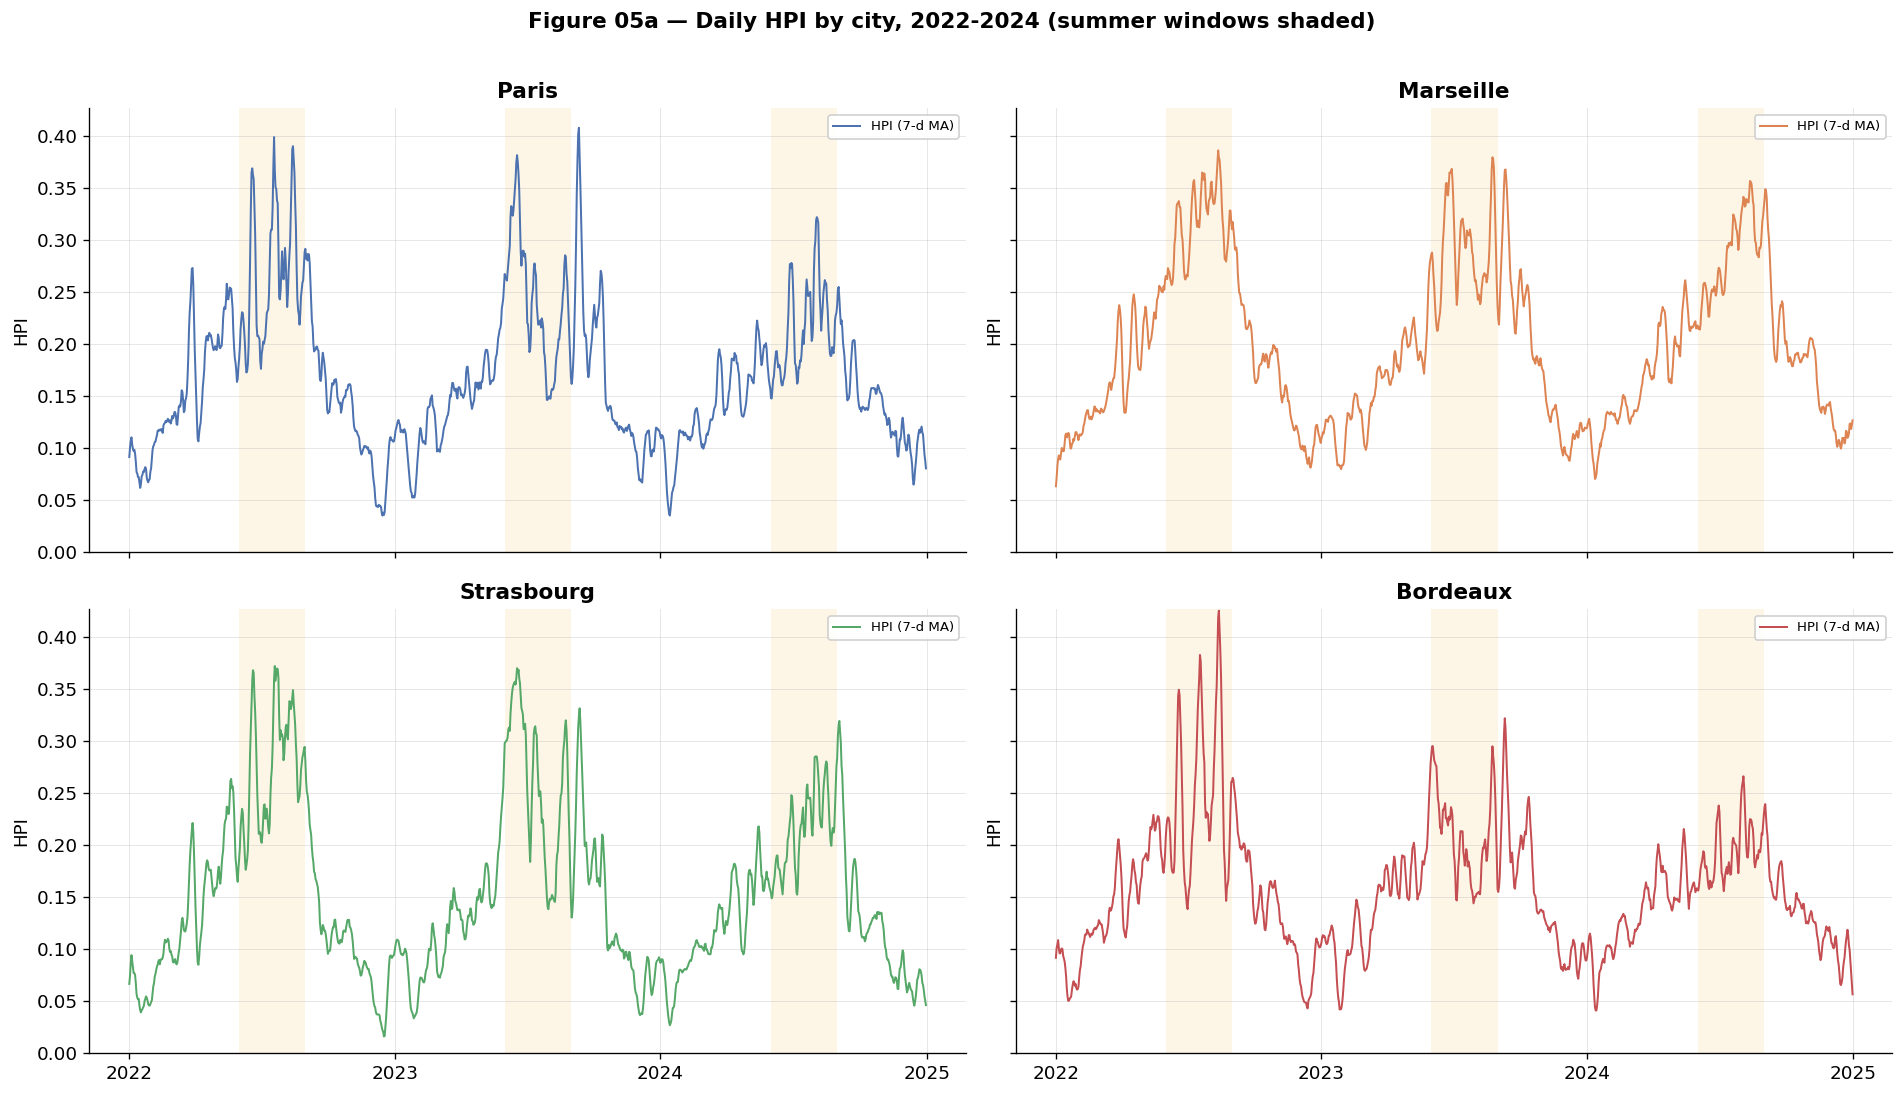

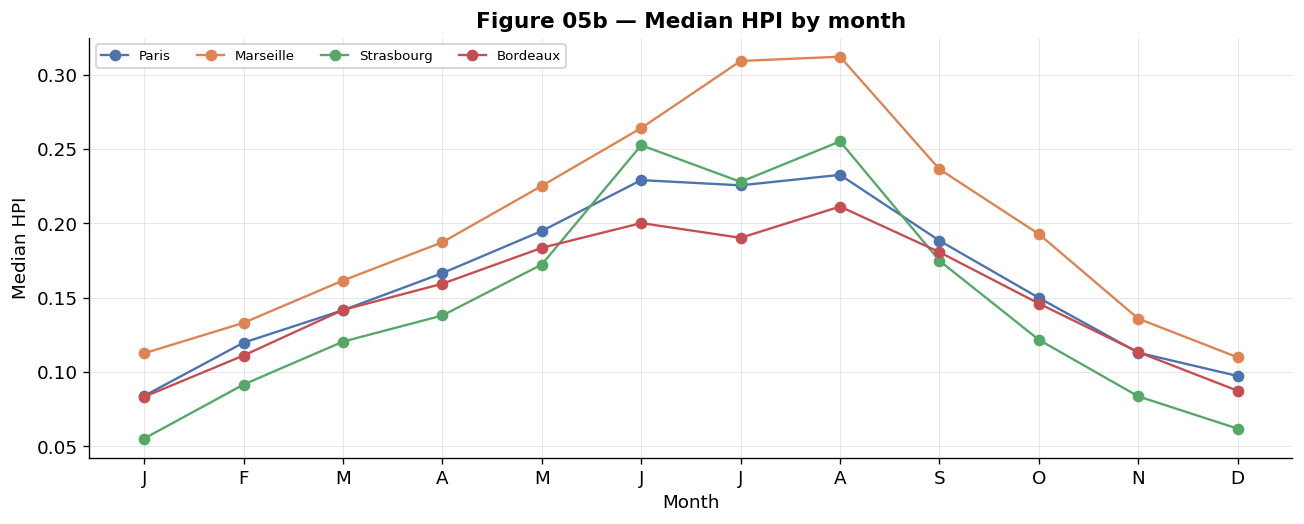

In [6]:
# ── Fig 05a: HPI by city over 2022-2024 — summer peaks check ───────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True)
for ax, city in zip(axes.flat, CITIES):
    sub = df[df["city"] == city].sort_values("date")
    hpi_7d = sub["HPI"].rolling(7, min_periods=1).mean()
    ax.plot(sub["date"], hpi_7d, color=CITY_COLORS[city], linewidth=1.2, label="HPI (7-d MA)")
    for year in (2022, 2023, 2024):
        ax.axvspan(pd.Timestamp(f"{year}-06-01"), pd.Timestamp(f"{year}-08-31"),
                   color="#f2c14e", alpha=0.14, linewidth=0)
    ax.set_title(city)
    ax.set_ylabel("HPI")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Figure 05a — Daily HPI by city, 2022-2024 (summer windows shaded)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_hpi_timeseries_by_city.png"), bbox_inches="tight", dpi=200)
plt.show()

# Compact seasonality diagnostic: median HPI by calendar month.
monthly_hpi = df.groupby(["city", "month"])["HPI"].median().reset_index()
fig, ax = plt.subplots(figsize=(11, 4.5))
for city in CITIES:
    sub = monthly_hpi[monthly_hpi["city"] == city]
    ax.plot(sub["month"], sub["HPI"], marker="o", linewidth=1.4,
            color=CITY_COLORS[city], label=city)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_title("Figure 05b — Median HPI by month")
ax.set_xlabel("Month")
ax.set_ylabel("Median HPI")
ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_hpi_monthly_seasonality.png"), bbox_inches="tight", dpi=200)
plt.show()


## 3 — EDA: HPI × pollen

Three diagnostics, each applying a lesson learnt in NB01–04:

- **§3.1 — Spearman by lag (0 … 14 days).** Biological response to heat/pollution is delayed: phenology is triggered by accumulated warmth, not day-of-exposure temperature. NB02 showed lag-3 to lag-7 relevance for weather; we verify whether HPI inherits this property. **(Remediates lesson `lessons.md:10` — "lagged cross-correlations shown but ARIMAX used lag-0".)**
- **§3.2 — Cross-city heatmap at optimal lag.** Quick visual: where does HPI pay off?
- **§3.3 — VIF on the candidate design matrix.** HPI is a linear combination of $T^{\max}$, O₃, NO₂. If ARIMAX ingests HPI *and* these raw components, perfect collinearity follows. The VIF test confirms which subset can coexist. **(Remediates lesson `lessons.md:7` — "no VIF computed before injecting correlated covariates".)**

Spearman (rank correlation) is used throughout — both pollen concentrations (heavily right-skewed, zero-inflated) and HPI distributions are non-Gaussian, so Pearson is not appropriate.

In [7]:
# ── §3.1 Lagged Spearman — HPI leads pollen by k days, k ∈ {0..14} ──────────
POLLEN_SPECIES = [
    "birch_pollen", "alder_pollen", "grass_pollen",
    "olive_pollen", "mugwort_pollen", "ragweed_pollen",
]
MAX_LAG = 14

def lagged_spearman(x, y, max_lag=MAX_LAG):
    """Return array of length max_lag+1 — ρ(x_{t-k}, y_t), k=0..max_lag."""
    rhos = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        if k == 0:
            a, b = x, y
        else:
            a, b = x.iloc[:-k], y.iloc[k:]
        rho, _ = stats.spearmanr(a, b, nan_policy="omit")
        rhos[k] = rho
    return rhos

rho_records = []
for city in CITIES:
    sub = df[df["city"] == city].sort_values("date").reset_index(drop=True)
    for sp in POLLEN_SPECIES:
        rhos = lagged_spearman(sub["HPI"], sub[sp])
        k_opt = int(np.argmax(np.abs(rhos)))
        rho_records.append({
            "city": city, "species": sp,
            "rho_lag0": rhos[0],
            "rho_opt": rhos[k_opt],
            "lag_opt": k_opt,
            "rhos": rhos,
        })
rho_df = pd.DataFrame(rho_records)
print("Optimal HPI lag per (city, species) — absolute-ρ maximum within 0-14 days:")
display(rho_df[["city", "species", "rho_lag0", "rho_opt", "lag_opt"]].round(3))

Optimal HPI lag per (city, species) — absolute-ρ maximum within 0-14 days:


,city,species,rho_lag0,rho_opt,lag_opt
0,Paris,birch_pollen,0.233,0.233,0
1,Paris,alder_pollen,-0.149,-0.340,14
2,Paris,grass_pollen,0.691,0.691,0
3,Paris,olive_pollen,0.210,0.231,1
4,Paris,mugwort_pollen,0.598,0.643,14
5,Paris,ragweed_pollen,0.386,0.402,14
6,Marseille,birch_pollen,0.168,0.168,0
7,Marseille,alder_pollen,-0.210,-0.412,14
8,Marseille,grass_pollen,0.700,0.700,0
9,Marseille,olive_pollen,0.330,0.330,0


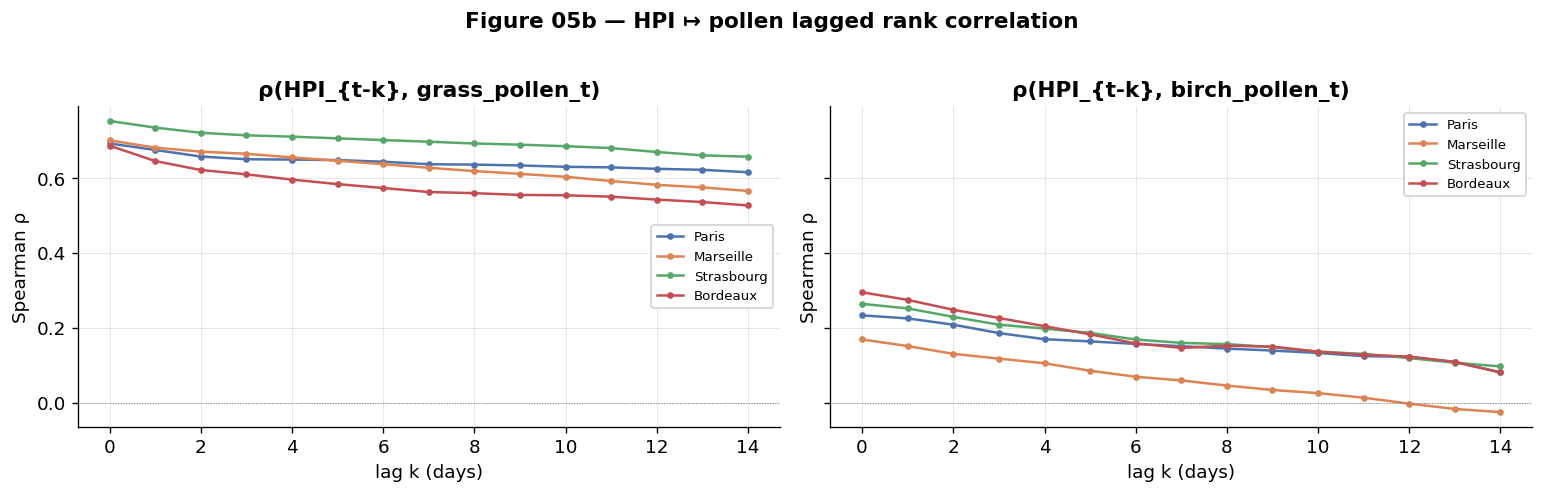

In [8]:
# ── Fig 05b: lagged Spearman curves for the two focal species ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, sp in zip(axes, ["grass_pollen", "birch_pollen"]):
    for city in CITIES:
        row = rho_df[(rho_df["city"] == city) & (rho_df["species"] == sp)].iloc[0]
        ax.plot(range(MAX_LAG + 1), row["rhos"], color=CITY_COLORS[city], marker="o", markersize=3, label=city)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle=":")
    ax.set_title(f"ρ(HPI_{{t-k}}, {sp}_t)")
    ax.set_xlabel("lag k (days)"); ax.set_ylabel("Spearman ρ")
    ax.legend(fontsize=8)
fig.suptitle("Figure 05b — HPI ↦ pollen lagged rank correlation", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_hpi_lagged_spearman.png"), bbox_inches="tight", dpi=200)
plt.show()

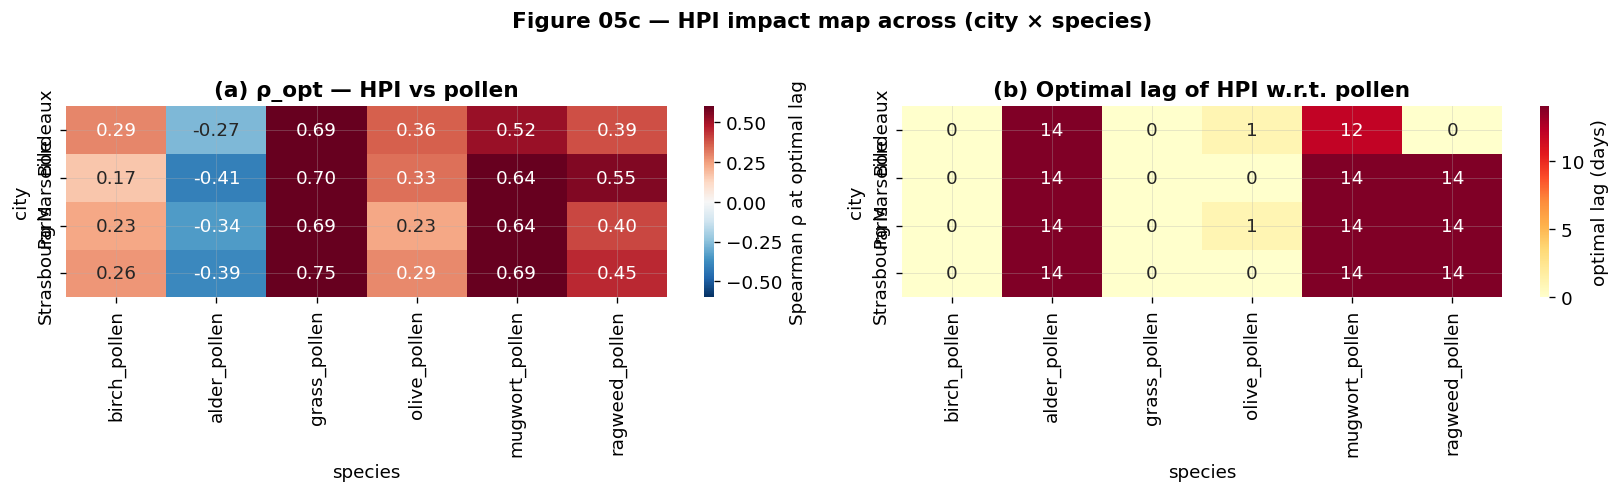

In [9]:
# ── §3.2 Cross-city heatmap of ρ_opt and optimal lag ────────────────────────
rho_pivot = rho_df.pivot(index="city", columns="species", values="rho_opt")[POLLEN_SPECIES]
lag_pivot = rho_df.pivot(index="city", columns="species", values="lag_opt")[POLLEN_SPECIES]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(rho_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
            ax=axes[0], cbar_kws={"label": "Spearman ρ at optimal lag"})
axes[0].set_title("(a) ρ_opt — HPI vs pollen")

sns.heatmap(lag_pivot, annot=True, fmt="d", cmap="YlOrRd",
            ax=axes[1], cbar_kws={"label": "optimal lag (days)"})
axes[1].set_title("(b) Optimal lag of HPI w.r.t. pollen")

fig.suptitle("Figure 05c — HPI impact map across (city × species)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_hpi_city_species_heatmap.png"), bbox_inches="tight", dpi=200)
plt.show()

In [10]:
# ── §3.3 VIF on candidate design matrix ─────────────────────────────────────
def compute_vif(X):
    """Return VIF per column — flag >5 as collinear."""
    X = X.assign(const=1.0)
    vifs = {col: variance_inflation_factor(X.values, X.columns.get_loc(col))
            for col in X.columns if col != "const"}
    return pd.Series(vifs).round(2)

# Two candidate specs, inspected on Paris (worst-case urban pollution)
sub = df[df["city"] == "Paris"].sort_values("date")

spec_A = ["HPI", "temperature_2m_max", "ozone", "nitrogen_dioxide", "sunshine_duration", "relative_humidity_2m_mean"]
spec_B = ["HPI", "sunshine_duration", "relative_humidity_2m_mean", "precipitation_sum"]

vif_A = compute_vif(sub[spec_A])
vif_B = compute_vif(sub[spec_B])
print("Spec A — HPI alongside its raw components (expect high VIF on components):")
display(vif_A.to_frame("VIF"))
print("\nSpec B — HPI + orthogonal weather (expect VIF < 5 throughout):")
display(vif_B.to_frame("VIF"))
print("Conclusion: §5 ARIMAX will use the Spec-B style — HPI + sunshine + humidity + precipitation.")

Spec A — HPI alongside its raw components (expect high VIF on components):


,VIF
HPI,43.12
temperature_2m_max,28.80
ozone,19.35
nitrogen_dioxide,16.24
sunshine_duration,2.45
relative_humidity_2m_mean,3.03



Spec B — HPI + orthogonal weather (expect VIF < 5 throughout):


,VIF
HPI,2.26
sunshine_duration,2.32
relative_humidity_2m_mean,2.62
precipitation_sum,1.17


Conclusion: §5 ARIMAX will use the Spec-B style — HPI + sunshine + humidity + precipitation.


## 4 — Visual HPI Validation Before Modelling

Before using HPI as an exogenous regressor, we validate three expected behaviours:

1. **Time series shape:** HPI should peak during summer because heat and photochemical pollution co-occur more often.
2. **Inter-annual summer comparison:** compare mean JJA HPI for 2022, 2023 and 2024 by city.
3. **Paris vs Bordeaux sanity check:** Paris should have a higher average HPI than Bordeaux because NO2 exposure is structurally higher in the Paris grid cell. If this check fails, the index definition should be revisited before modelling.


In [11]:
# ── §4.1 Summer JJA stats: 2022 vs 2023 vs 2024 per city ───────────────────
df["season"] = np.where(df["month"].isin([6, 7, 8]), "JJA", "other")
jja = df[(df["season"] == "JJA") & (df["year"].isin([2022, 2023, 2024]))].copy()

summary = []
for city in CITIES:
    for yr in (2022, 2023, 2024):
        sub = jja[(jja["city"] == city) & (jja["year"] == yr)]
        summary.append({
            "city": city, "year": yr, "n_days": len(sub),
            "HPI_mean": sub["HPI"].mean(),
            "HPI_median": sub["HPI"].median(),
            "HPI_p90": sub["HPI"].quantile(0.90),
            "Tmax_mean": sub["temperature_2m_max"].mean(),
            "O3_mean": sub["ozone"].mean(),
            "NO2_mean": sub["nitrogen_dioxide"].mean(),
        })
summary_df = pd.DataFrame(summary)
print("JJA HPI summary by city and year:")
display(summary_df.round(3))

summer_hpi_pivot = summary_df.pivot(index="city", columns="year", values="HPI_mean")
print("\nMean JJA HPI pivot:")
display(summer_hpi_pivot.round(3))

overall_hpi = df.groupby("city")["HPI"].mean()
jja_hpi = jja.groupby("city")["HPI"].mean()
paris_bordeaux_check = pd.DataFrame([
    {"scope": "All days 2022-2024", "Paris": overall_hpi["Paris"], "Bordeaux": overall_hpi["Bordeaux"],
     "Paris_gt_Bordeaux": bool(overall_hpi["Paris"] > overall_hpi["Bordeaux"])},
    {"scope": "JJA only 2022-2024", "Paris": jja_hpi["Paris"], "Bordeaux": jja_hpi["Bordeaux"],
     "Paris_gt_Bordeaux": bool(jja_hpi["Paris"] > jja_hpi["Bordeaux"])},
])
print("\nParis vs Bordeaux HPI sanity check:")
display(paris_bordeaux_check.round(3))

if not paris_bordeaux_check["Paris_gt_Bordeaux"].all():
    print("WARNING: Paris is not above Bordeaux on every requested check; revisit HPI scaling/weights before modelling.")
else:
    print("Sanity check passed: Paris > Bordeaux for both all-day and JJA mean HPI.")

# Mann-Whitney per city for year-to-year summer differences.
mw_rows = []
for city in CITIES:
    for y0, y1 in [(2022, 2023), (2023, 2024), (2022, 2024)]:
        x = jja.loc[(jja["city"] == city) & (jja["year"] == y0), "HPI"].values
        y = jja.loc[(jja["city"] == city) & (jja["year"] == y1), "HPI"].values
        stat, pval = stats.mannwhitneyu(y, x, alternative="two-sided")
        mw_rows.append({
            "city": city, "comparison": f"{y1} vs {y0}", "U": stat, "p_value": pval,
            "mean_delta": float(np.mean(y) - np.mean(x)),
            "significant_5pct": pval < 0.05,
        })
mw_df = pd.DataFrame(mw_rows)
print("\nMann-Whitney U on JJA HPI, per city:")
display(mw_df.round({"p_value": 4, "mean_delta": 3}))


JJA HPI summary by city and year:


,city,year,n_days,HPI_mean,HPI_median,HPI_p90,Tmax_mean,O3_mean,NO2_mean
0,Paris,2022,92,0.271,0.244,0.427,26.271,66.457,16.160
1,Paris,2023,92,0.240,0.227,0.339,25.107,63.652,13.976
2,Paris,2024,92,0.220,0.202,0.304,23.816,62.361,13.007
3,Marseille,2022,92,0.318,0.322,0.380,28.442,85.529,11.003
4,Marseille,2023,92,0.288,0.275,0.374,27.811,81.139,9.024
5,Marseille,2024,92,0.291,0.291,0.359,27.849,80.093,10.176
6,Strasbourg,2022,92,0.279,0.275,0.367,27.834,77.620,8.997
7,Strasbourg,2023,92,0.254,0.259,0.361,26.185,69.753,11.008
8,Strasbourg,2024,92,0.223,0.215,0.323,24.809,66.614,9.222
9,Bordeaux,2022,92,0.252,0.233,0.392,28.690,71.916,5.462



Mean JJA HPI pivot:


year,2022,2023,2024
city,,,
Bordeaux,0.252,0.204,0.197
Marseille,0.318,0.288,0.291
Paris,0.271,0.240,0.220
Strasbourg,0.279,0.254,0.223



Paris vs Bordeaux HPI sanity check:


,scope,Paris,Bordeaux,Paris_gt_Bordeaux
0,All days 2022-2024,0.169,0.157,True
1,JJA only 2022-2024,0.244,0.218,True


Sanity check passed: Paris > Bordeaux for both all-day and JJA mean HPI.

Mann-Whitney U on JJA HPI, per city:


,city,comparison,U,p_value,mean_delta,significant_5pct
0,Paris,2023 vs 2022,3417.0,0.0241,-0.030,True
1,Paris,2024 vs 2023,3625.0,0.0932,-0.020,False
2,Paris,2024 vs 2022,2720.0,0.0000,-0.050,True
3,Marseille,2023 vs 2022,2850.0,0.0001,-0.030,True
4,Marseille,2024 vs 2023,4490.0,0.4759,0.003,False
5,Marseille,2024 vs 2022,2983.0,0.0005,-0.027,True
6,Strasbourg,2023 vs 2022,3561.0,0.0634,-0.026,False
7,Strasbourg,2024 vs 2023,3417.0,0.0241,-0.031,True
8,Strasbourg,2024 vs 2022,2358.0,0.0000,-0.057,True
9,Bordeaux,2023 vs 2022,2974.0,0.0005,-0.048,True


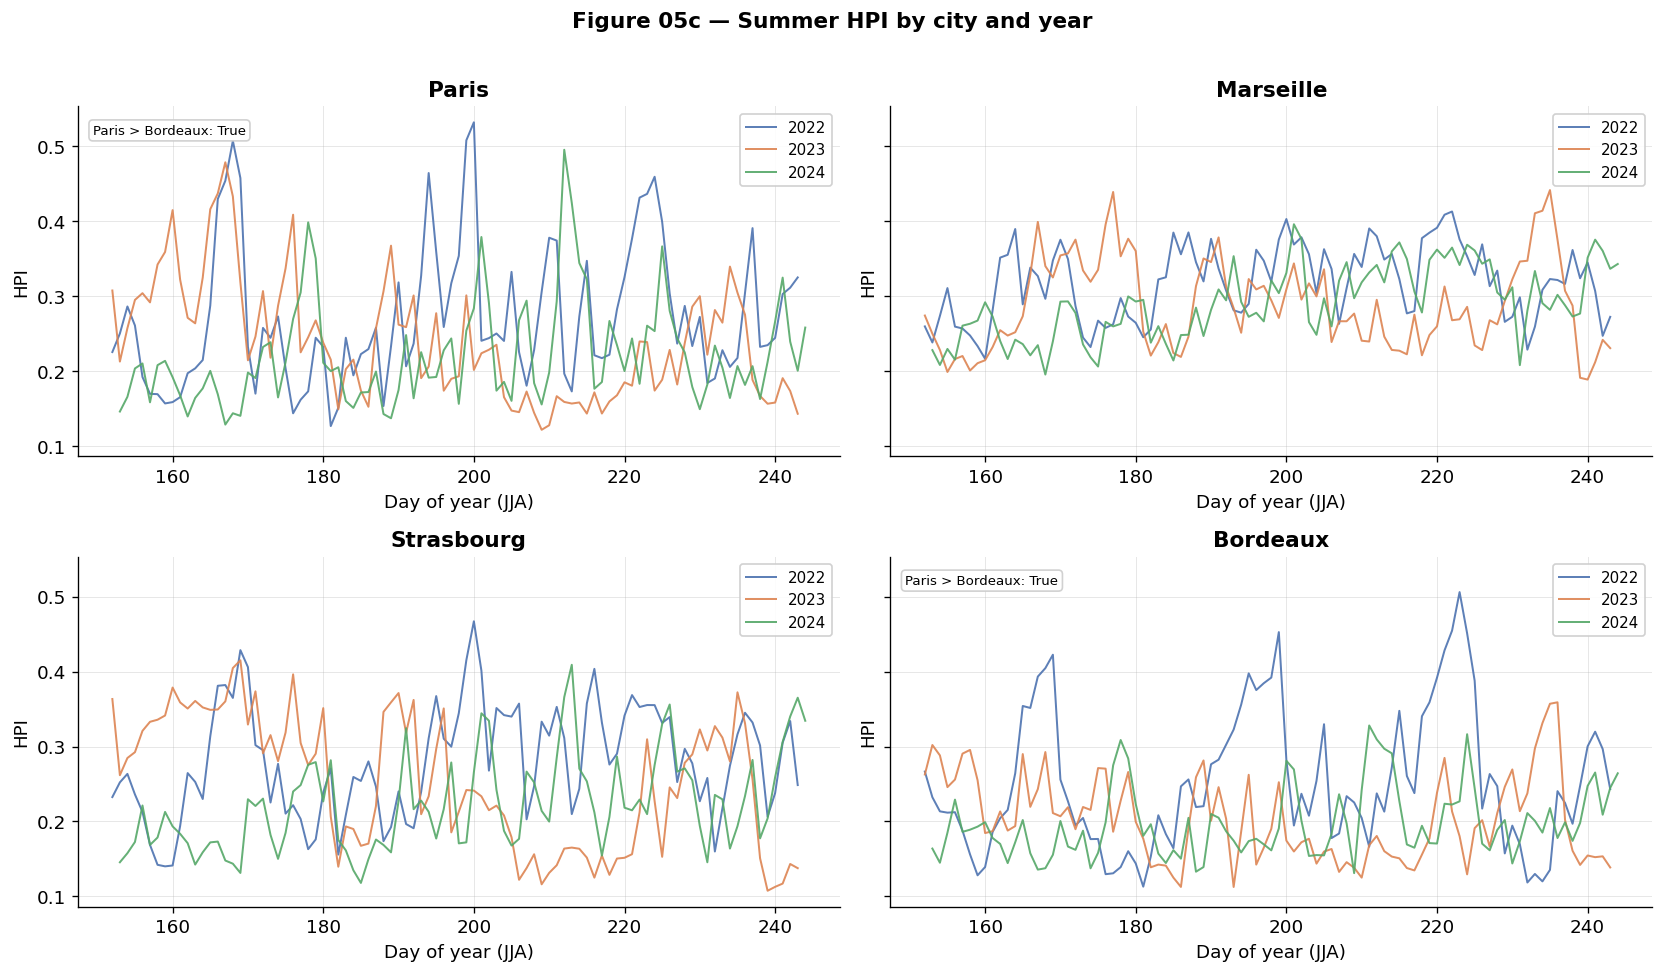

In [12]:
# ── Fig 05c: JJA HPI comparison, 2022 vs 2023 vs 2024 ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, city in zip(axes.flat, CITIES):
    for yr in (2022, 2023, 2024):
        sub = jja[(jja["city"] == city) & (jja["year"] == yr)].sort_values("date")
        ax.plot(sub["day_of_year"], sub["HPI"], color=YEAR_COLORS[yr],
                linewidth=1.2, alpha=0.9, label=f"{yr}")
    ax.set_title(city)
    ax.set_xlabel("Day of year (JJA)")
    ax.set_ylabel("HPI")
    ax.legend(fontsize=9, loc="upper right")
    row = paris_bordeaux_check[paris_bordeaux_check["scope"] == "JJA only 2022-2024"].iloc[0]
    if city in ["Paris", "Bordeaux"]:
        ax.annotate(
            f"Paris > Bordeaux: {row['Paris_gt_Bordeaux']}",
            xy=(0.02, 0.95), xycoords="axes fraction", fontsize=8, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9),
        )
fig.suptitle("Figure 05c — Summer HPI by city and year", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_summer_hpi_by_year.png"), bbox_inches="tight", dpi=200)
plt.show()


## 5 — Residual Analysis of the NB03 ARIMA+Fourier Model

We now reuse the NB03 baseline logic: ARIMA on $\log(1+x)$ with Fourier seasonality, no weather or pollution regressors. The diagnostic question is empirical:

> Do the largest 2024 forecast residuals tend to occur on high-HPI days?

For each city, we compare absolute residuals with HPI using Spearman correlation and a top-residual-days overlap check. A strong positive pattern means the pollen-only seasonal model is missing heat-pollution stress days.


ARIMA+Fourier residuals crossed with HPI (grass, 2024 test):


,city,order,RMSE_2024,spearman_abs_resid_HPI,spearman_p_value,top10_resid_days,mean_HPI_top10_resid,mean_HPI_other_days,top10_resid_days_high_HPI_pct
3,Bordeaux,"(0, 1, 3)",6.798,0.705,0.0,37,0.181,0.143,35.1
1,Marseille,"(0, 1, 4)",2.596,0.728,0.0,37,0.242,0.194,32.4
0,Paris,"(3, 1, 2)",3.883,0.549,0.0,37,0.193,0.154,29.7
2,Strasbourg,"(1, 0, 2)",5.326,0.725,0.0,37,0.181,0.137,27.0


hpi_residual_diagnostics.csv exported.


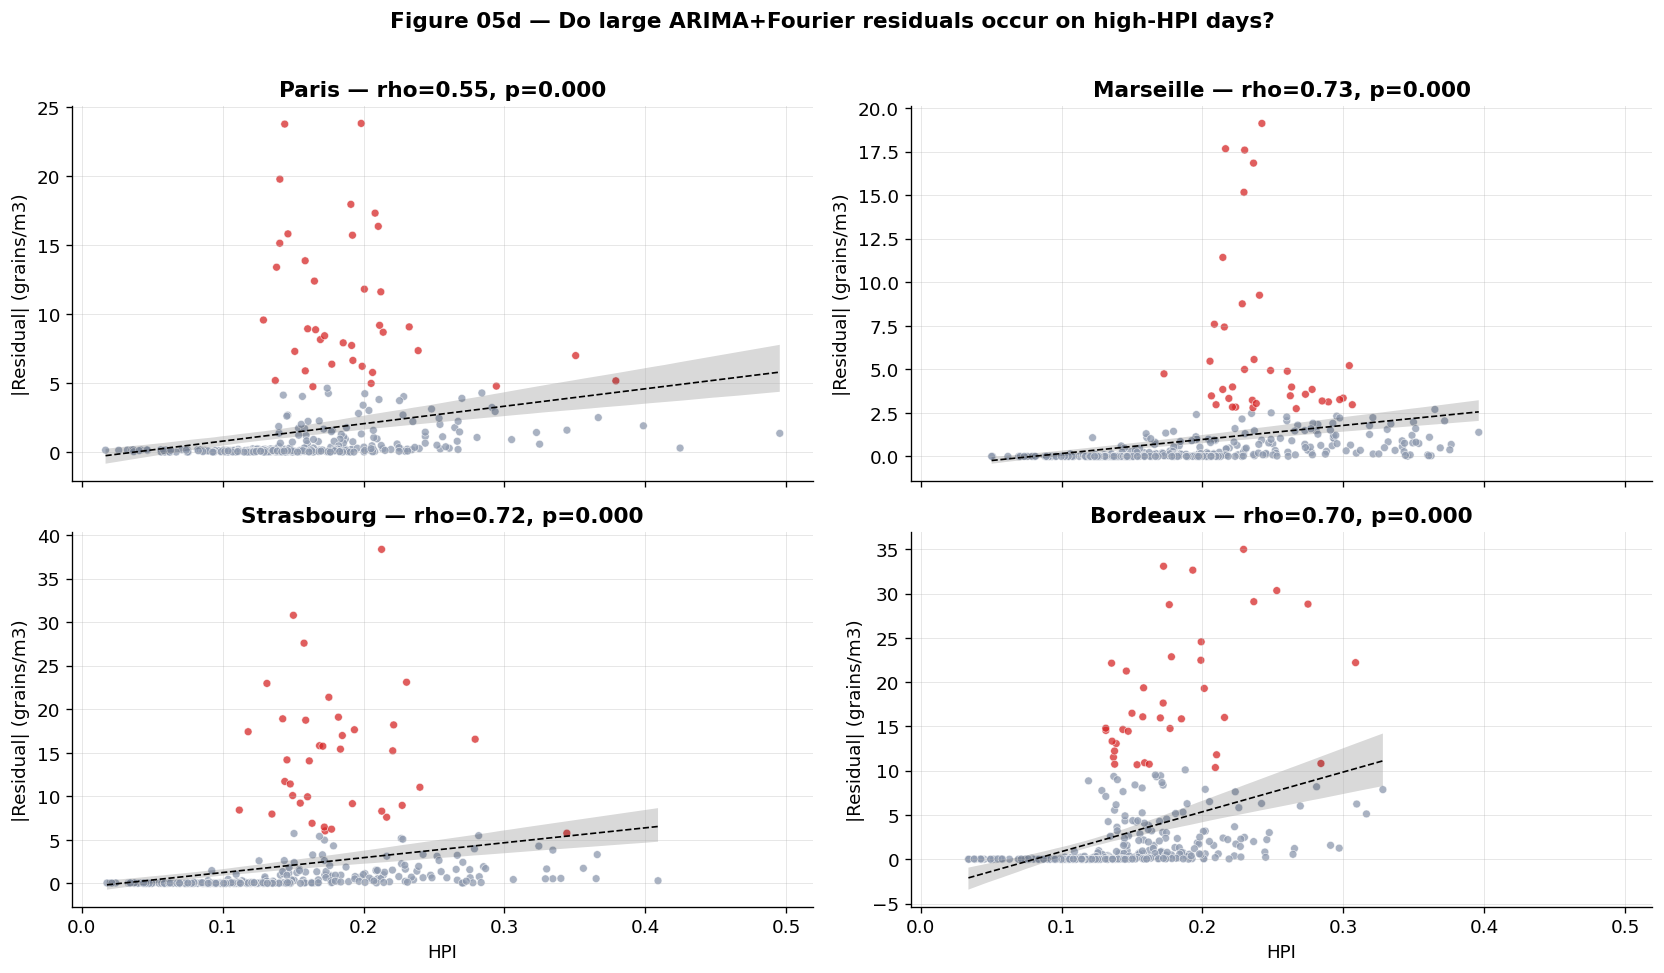

In [13]:
# ── §5.1 Fit ARIMA+Fourier residuals and cross them with HPI ───────────────
RESID_TRAIN_END = "2023-12-31"
RESID_TEST_START = "2024-01-01"
FOURIER_K, FOURIER_PERIOD = 5, 365.25
PRIMARY_SPECIES = "grass_pollen"

def make_fourier(dates, K=FOURIER_K, period=FOURIER_PERIOD, offset=0):
    """Generate 2K Fourier regressors with a continuous phase offset."""
    t = np.arange(len(dates)) + offset
    cols = {}
    for j in range(1, K + 1):
        cols[f"sin_{j}"] = np.sin(2 * np.pi * j * t / period)
        cols[f"cos_{j}"] = np.cos(2 * np.pi * j * t / period)
    return pd.DataFrame(cols, index=dates if isinstance(dates, pd.DatetimeIndex) else None)

def log_transform(x):
    return np.log1p(x)

def inv_log_transform(y):
    return np.clip(np.expm1(y), 0, None)

def compute_metrics(actual, predicted, label=""):
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    return {
        "Model": label,
        "RMSE": float(np.sqrt(mean_squared_error(a, p))),
        "MAE": float(mean_absolute_error(a, p)),
        "MAPE*": float(100 * np.mean(np.abs(a - p) / (a + 1.0))),
    }

residual_rows = []
residual_daily = []
residual_forecasts = {}

for city in CITIES:
    cdf = df[df["city"] == city].set_index("date").sort_index()
    train_raw = cdf.loc[:RESID_TRAIN_END, PRIMARY_SPECIES]
    test_raw = cdf.loc[RESID_TEST_START:, PRIMARY_SPECIES]
    y_train, y_test = log_transform(train_raw), log_transform(test_raw)

    X_train = make_fourier(y_train.index, offset=0)
    X_test = make_fourier(y_test.index, offset=len(y_train))

    model = pm.auto_arima(
        y_train.values, X=X_train.values,
        start_p=0, max_p=5, start_q=0, max_q=5,
        d=None, max_d=2, seasonal=False, stepwise=True,
        suppress_warnings=True, information_criterion="aicc", error_action="ignore",
    )
    pred_raw = inv_log_transform(model.predict(n_periods=len(y_test), X=X_test.values))
    actual = test_raw.astype(float)
    resid = actual - pred_raw
    abs_resid = resid.abs()
    hpi_test = cdf.loc[test_raw.index, "HPI"]

    rho, pval = stats.spearmanr(abs_resid, hpi_test)
    big_resid_threshold = abs_resid.quantile(0.90)
    high_hpi_threshold = cdf["HPI"].quantile(0.75)
    big = abs_resid >= big_resid_threshold

    residual_rows.append({
        "city": city,
        "order": str(model.order),
        "RMSE_2024": compute_metrics(actual.values, pred_raw)["RMSE"],
        "spearman_abs_resid_HPI": rho,
        "spearman_p_value": pval,
        "top10_resid_days": int(big.sum()),
        "mean_HPI_top10_resid": float(hpi_test[big].mean()),
        "mean_HPI_other_days": float(hpi_test[~big].mean()),
        "top10_resid_days_high_HPI_pct": float(100 * (hpi_test[big] >= high_hpi_threshold).mean()),
    })

    city_daily = pd.DataFrame({
        "date": test_raw.index,
        "city": city,
        "actual": actual.values,
        "predicted": pred_raw,
        "residual": resid.values,
        "abs_residual": abs_resid.values,
        "HPI": hpi_test.values,
        "big_residual_day": big.values,
        "high_HPI_day": (hpi_test >= high_hpi_threshold).values,
    })
    residual_daily.append(city_daily)
    residual_forecasts[city] = city_daily

residual_summary = pd.DataFrame(residual_rows).sort_values("city")
residual_daily = pd.concat(residual_daily, ignore_index=True)
print("ARIMA+Fourier residuals crossed with HPI (grass, 2024 test):")
display(residual_summary.round({
    "RMSE_2024": 3,
    "spearman_abs_resid_HPI": 3,
    "spearman_p_value": 4,
    "mean_HPI_top10_resid": 3,
    "mean_HPI_other_days": 3,
    "top10_resid_days_high_HPI_pct": 1,
}))

residual_daily.to_csv(os.path.join(DATA_PROC, "hpi_residual_diagnostics.csv"), index=False)
print("hpi_residual_diagnostics.csv exported.")

# Visual diagnostic: if the slope/cloud is positive, HPI explains missed days.
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=False)
for ax, city in zip(axes.flat, CITIES):
    sub = residual_forecasts[city]
    sns.scatterplot(data=sub, x="HPI", y="abs_residual", hue="big_residual_day",
                    palette={False: "#8d99ae", True: "#d62828"}, s=22, alpha=0.75,
                    ax=ax, legend=False)
    sns.regplot(data=sub, x="HPI", y="abs_residual", scatter=False,
                color="black", line_kws={"linewidth": 1.0, "linestyle": "--"}, ax=ax)
    row = residual_summary[residual_summary["city"] == city].iloc[0]
    ax.set_title(f"{city} — rho={row['spearman_abs_resid_HPI']:.2f}, p={row['spearman_p_value']:.3f}")
    ax.set_xlabel("HPI")
    ax.set_ylabel("|Residual| (grains/m3)")
fig.suptitle("Figure 05d — Do large ARIMA+Fourier residuals occur on high-HPI days?",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_residuals_vs_hpi.png"), bbox_inches="tight", dpi=200)
plt.show()


## 6 — ARIMAX + HPI Modelling

### 6.1 — Experimental design

We keep the NB03 deterministic Fourier seasonality ($2K = 10$, $T = 365.25$, $K = 5$), then compare three families:

| Family | Exogenous variables | Purpose |
|:---|:---|:---|
| **M1_weather** | temperature + sunshine lags from NB03 | Baseline without HPI |
| **M2_hpi_lag{k}** | HPI at lag $k \in \{0,1,3,7\}$ | Tests whether HPI can replace temperature + sunshine |
| **M3_weather_hpi_lag{k}** | M1 weather features + HPI at lag $k \in \{0,1,3,7\}$ | Tests whether HPI adds incremental information |

The lag grid explicitly tests instant and delayed heat-pollution effects: $t$, $t-1$, $t-3$, $t-7$.

### 6.2 — Split honouring anti-leakage lesson

**Train 2022 / validation 2023 / test 2024.** Order $(p, d, q)$ is selected per (city, species, model) via `auto_arima` on **train**, evaluated on **val**, then refit on 2022 + 2023 and scored on 2024 once.

### 6.3 — Prediction intervals

Residual bootstrap intervals are kept because NB03 residuals were non-normal. The main comparison is RMSE and skill score versus **M1_weather**.


In [14]:
# ── Helpers — reused / adapted from NB03 ────────────────────────────────────
TRAIN_END = "2022-12-31"
VAL_START, VAL_END = "2023-01-01", "2023-12-31"
TEST_START = "2024-01-01"
FOURIER_K, FOURIER_PERIOD = 5, 365.25

MODEL_SPECIES = ["grass_pollen", "birch_pollen", "olive_pollen"]  # focal species from NB03/NB04
HPI_LAGS = [0, 1, 3, 7]
MODEL_SPECS = ["M1_weather"] + [f"M2_hpi_lag{lag}" for lag in HPI_LAGS] + [f"M3_weather_hpi_lag{lag}" for lag in HPI_LAGS]

def model_family(spec):
    if spec == "M1_weather":
        return "M1_weather"
    if spec.startswith("M2_hpi"):
        return "M2_hpi_only"
    if spec.startswith("M3_weather_hpi"):
        return "M3_weather_plus_hpi"
    raise ValueError(spec)

def parse_hpi_lag(spec):
    return int(spec.rsplit("lag", 1)[1]) if "lag" in spec else np.nan

def make_fourier(dates, K=FOURIER_K, period=FOURIER_PERIOD, offset=0):
    """Generate 2K Fourier regressors. `offset` lets later blocks continue the same phase."""
    t = np.arange(len(dates)) + offset
    cols = {}
    for j in range(1, K + 1):
        cols[f"sin_{j}"] = np.sin(2 * np.pi * j * t / period)
        cols[f"cos_{j}"] = np.cos(2 * np.pi * j * t / period)
    return pd.DataFrame(cols, index=dates if isinstance(dates, pd.DatetimeIndex) else None)

def log_transform(x):
    return np.log1p(x)

def inv_log_transform(y):
    return np.clip(np.expm1(y), 0, None)

def compute_metrics(actual, predicted, label=""):
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    rmse = float(np.sqrt(mean_squared_error(a, p)))
    mae = float(mean_absolute_error(a, p))
    mape = float(100 * np.mean(np.abs(a - p) / (a + 1.0)))
    return {"Model": label, "RMSE": rmse, "MAE": mae, "MAPE*": mape}

print(f"Helpers ready. Specs={len(MODEL_SPECS)} | Train:{TRAIN_END} | Val:{VAL_START}..{VAL_END} | Test:{TEST_START}..")


Helpers ready. Specs=9 | Train:2022-12-31 | Val:2023-01-01..2023-12-31 | Test:2024-01-01..


In [15]:
# ── Feature builders, one per model specification ───────────────────────────
def _city_frame(city):
    """Return the per-city dataframe indexed by date and sorted."""
    return df[df["city"] == city].set_index("date").sort_index().copy()

def _weather_baseline_features(city_df):
    """NB03-style weather baseline: temperature and sunshine with selected lags."""
    return pd.DataFrame({
        "temperature_2m_mean": city_df["temperature_2m_mean"],
        "temperature_2m_mean_lag3": city_df["temperature_2m_mean"].shift(3),
        "sunshine_duration": city_df["sunshine_duration"],
        "sunshine_duration_lag7": city_df["sunshine_duration"].shift(7),
    }, index=city_df.index)

def build_exog(city_df, spec):
    """Return exogenous features excluding Fourier for a model specification."""
    out = pd.DataFrame(index=city_df.index)
    if spec == "M1_weather":
        out = _weather_baseline_features(city_df)
    elif spec.startswith("M2_hpi_lag"):
        lag = parse_hpi_lag(spec)
        out[f"HPI_lag{lag}"] = city_df["HPI"].shift(lag)
    elif spec.startswith("M3_weather_hpi_lag"):
        lag = parse_hpi_lag(spec)
        out = _weather_baseline_features(city_df)
        out[f"HPI_lag{lag}"] = city_df["HPI"].shift(lag)
    else:
        raise ValueError(spec)
    return out.ffill().bfill()

print("Feature builders ready.")


Feature builders ready.


In [ ]:
# ── Fit weather baseline + HPI lag specifications per (city, species) ───────
def fit_and_score(y_train, X_train, y_val, X_val, y_test, X_test, label):
    """auto_arima on train, score on val; refit on train+val, score on test."""
    model = pm.auto_arima(
        y_train.values, X=X_train.values,
        start_p=0, max_p=5, start_q=0, max_q=5, d=None, max_d=2,
        seasonal=False, stepwise=True, suppress_warnings=True,
        information_criterion="aicc", error_action="ignore",
    )
    order = model.order
    val_pred = inv_log_transform(model.predict(n_periods=len(y_val), X=X_val.values))
    val_metrics = compute_metrics(inv_log_transform(y_val.values), val_pred, label=label + ":val")

    # Refit on train+val at the selected order then score on test.
    y_tv = pd.concat([y_train, y_val])
    X_tv = pd.concat([X_train, X_val])
    final = pm.ARIMA(order=order, suppress_warnings=True)
    final.fit(y_tv.values, X=X_tv.values)
    test_point = final.predict(n_periods=len(y_test), X=X_test.values)
    test_pred = inv_log_transform(test_point)
    test_metrics = compute_metrics(inv_log_transform(y_test.values), test_pred, label=label + ":test")

    residuals = final.resid()
    B = 500
    rng = np.random.default_rng(42)
    boots = np.empty((B, len(y_test)))
    for b in range(B):
        idx = rng.integers(0, len(residuals), size=len(y_test))
        boots[b] = inv_log_transform(test_point + residuals[idx])
    lo = np.quantile(boots, 0.025, axis=0)
    hi = np.quantile(boots, 0.975, axis=0)
    return {
        "order": order,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "test_pred": test_pred,
        "test_lo": lo, "test_hi": hi,
    }

RESULTS = []
FORECASTS = {}

for city in CITIES:
    cdf = _city_frame(city)
    train_idx = cdf.loc[:TRAIN_END].index
    val_idx = cdf.loc[VAL_START:VAL_END].index
    test_idx = cdf.loc[TEST_START:].index
    F_tr = make_fourier(train_idx, offset=0)
    F_va = make_fourier(val_idx, offset=len(train_idx))
    F_te = make_fourier(test_idx, offset=len(train_idx) + len(val_idx))

    for sp in MODEL_SPECIES:
        y_full = log_transform(cdf[sp])
        y_tr, y_va, y_te = y_full.loc[train_idx], y_full.loc[val_idx], y_full.loc[test_idx]

        for spec in MODEL_SPECS:
            E_full = build_exog(cdf, spec)
            E_tr = pd.concat([F_tr, E_full.loc[train_idx].reset_index(drop=True).set_index(train_idx)], axis=1)
            E_va = pd.concat([F_va, E_full.loc[val_idx].reset_index(drop=True).set_index(val_idx)], axis=1)
            E_te = pd.concat([F_te, E_full.loc[test_idx].reset_index(drop=True).set_index(test_idx)], axis=1)
            label = f"{city}|{sp}|{spec}"
            try:
                res = fit_and_score(y_tr, E_tr, y_va, E_va, y_te, E_te, label=label)
                RESULTS.append({
                    "city": city,
                    "species": sp,
                    "model": spec,
                    "family": model_family(spec),
                    "hpi_lag": parse_hpi_lag(spec),
                    "order": str(res["order"]),
                    "RMSE_val": res["val_metrics"]["RMSE"],
                    "RMSE_test": res["test_metrics"]["RMSE"],
                    "MAE_test": res["test_metrics"]["MAE"],
                    "MAPE_test": res["test_metrics"]["MAPE*"],
                })
                FORECASTS[(city, sp, spec)] = {
                    "test_idx": test_idx,
                    "test_actual": inv_log_transform(y_te.values),
                    "test_pred": res["test_pred"],
                    "test_lo": res["test_lo"], "test_hi": res["test_hi"],
                }
            except Exception as e:
                print(f"[skip] {label}: {e}")

res_df = pd.DataFrame(RESULTS).sort_values(["city", "species", "family", "hpi_lag", "model"]).reset_index(drop=True)
print(f"Trained {len(res_df)} (city × species × model) combinations.")
display(res_df.round({"RMSE_val": 3, "RMSE_test": 3, "MAE_test": 3, "MAPE_test": 2}))


## 7 — Model Comparison

- **Lag test.** For each city and species, compare HPI lags $t$, $t-1$, $t-3$ and $t-7$.
- **Skill score.** All HPI candidates are compared to **M1_weather**:
$$\text{Skill}(M) = 1 - \frac{\text{RMSE}(M)}{\text{RMSE}(M1\_weather)}$$
- **Compact statistical test.** Friedman/Nemenyi is run on three columns per (city, species): M1 weather baseline, best HPI-only candidate, and best weather+HPI candidate.


In [ ]:
# ── RMSE, skill and best HPI lag per (city, species) ───────────────────────
piv = res_df.pivot(index=["city", "species"], columns="model", values="RMSE_test")
baseline = piv["M1_weather"]

skill = piv.drop(columns=["M1_weather"]).apply(lambda col: 1 - col / baseline, axis=0)
skill = skill.add_prefix("Skill_").round(3)
print("Test RMSE by model:")
display(piv.round(3))
print("\nSkill scores vs M1_weather (positive = HPI helps):")
display(skill)

best_rows = []
for (city, species), group in res_df.groupby(["city", "species"]):
    m1 = group[group["model"] == "M1_weather"].iloc[0]
    hpi_only = group[group["family"] == "M2_hpi_only"].sort_values("RMSE_test").iloc[0]
    hpi_plus = group[group["family"] == "M3_weather_plus_hpi"].sort_values("RMSE_test").iloc[0]
    best_rows.append({
        "city": city,
        "species": species,
        "RMSE_M1_weather": m1["RMSE_test"],
        "best_HPI_only_model": hpi_only["model"],
        "best_HPI_only_lag": int(hpi_only["hpi_lag"]),
        "RMSE_best_HPI_only": hpi_only["RMSE_test"],
        "Skill_best_HPI_only_vs_M1": 1 - hpi_only["RMSE_test"] / m1["RMSE_test"],
        "best_HPI_plus_model": hpi_plus["model"],
        "best_HPI_plus_lag": int(hpi_plus["hpi_lag"]),
        "RMSE_best_HPI_plus": hpi_plus["RMSE_test"],
        "Skill_best_HPI_plus_vs_M1": 1 - hpi_plus["RMSE_test"] / m1["RMSE_test"],
    })
best_lag_df = pd.DataFrame(best_rows).sort_values(["city", "species"])
print("\nBest HPI lag per city/species:")
display(best_lag_df.round({
    "RMSE_M1_weather": 3,
    "RMSE_best_HPI_only": 3,
    "Skill_best_HPI_only_vs_M1": 3,
    "RMSE_best_HPI_plus": 3,
    "Skill_best_HPI_plus_vs_M1": 3,
}))

comparison_for_tests = best_lag_df.set_index(["city", "species"])[[
    "RMSE_M1_weather", "RMSE_best_HPI_only", "RMSE_best_HPI_plus"
]].rename(columns={
    "RMSE_M1_weather": "M1_weather",
    "RMSE_best_HPI_only": "Best_HPI_only",
    "RMSE_best_HPI_plus": "Best_weather_plus_HPI",
})
ranks = comparison_for_tests.rank(axis=1, method="average")
print("\nCompact ranking table for Friedman/Nemenyi:")
display(comparison_for_tests.round(3))
display(ranks.round(2))


In [ ]:
# ── Friedman + Nemenyi on compact model families ───────────────────────────
from scipy.stats import friedmanchisquare

fr_stat, fr_pval = friedmanchisquare(
    comparison_for_tests["M1_weather"].values,
    comparison_for_tests["Best_HPI_only"].values,
    comparison_for_tests["Best_weather_plus_HPI"].values,
)
print(f"Friedman chi2 = {fr_stat:.3f}   p = {fr_pval:.4f}")

# Nemenyi critical difference (Demšar 2006): CD = q_alpha * sqrt(k(k+1)/(6N))
N, k = comparison_for_tests.shape[0], comparison_for_tests.shape[1]
q_alpha_05 = {2: 1.960, 3: 2.343, 4: 2.569}[k]
CD = q_alpha_05 * np.sqrt(k * (k + 1) / (6 * N))
mean_ranks = ranks.mean().sort_values()
print(f"\nN = {N} triples, k = {k} model families. Critical difference @alpha=0.05: CD = {CD:.3f}")
print("\nMean ranks (lower = better):")
display(mean_ranks.to_frame("mean_rank").round(3))

pairs = [("M1_weather", "Best_HPI_only"), ("M1_weather", "Best_weather_plus_HPI"), ("Best_HPI_only", "Best_weather_plus_HPI")]
pair_records = []
for a, b in pairs:
    delta = abs(mean_ranks[a] - mean_ranks[b])
    pair_records.append({"pair": f"{a} vs {b}", "abs_delta_rank": round(delta, 3),
                         "CD": round(CD, 3), "significant": delta > CD})
display(pd.DataFrame(pair_records))


In [ ]:
# ── Fig 05f: CD diagram + best HPI skill heatmap ───────────────────────────
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1.0], wspace=0.35)

# (a) Nemenyi-style critical difference diagram
ax_a = fig.add_subplot(gs[0, 0])
mr = mean_ranks.sort_values()
ax_a.set_xlim(0.5, k + 0.5)
ax_a.set_ylim(-1, 2)
ax_a.set_yticks([])
ax_a.spines["left"].set_visible(False)
ax_a.set_xticks(range(1, k + 1))
ax_a.set_xlabel("Mean rank  (1 = best)")
ax_a.set_title(f"(a) Friedman-Nemenyi — CD @ alpha=0.05 = {CD:.2f}")
for m, r in mr.items():
    ax_a.plot(r, 0, "o", markersize=9, color="black")
    ax_a.text(r, 0.35, m, ha="center", fontsize=9, fontweight="bold")
models_sorted = list(mr.index)
r_vals = mr.values
y_level = -0.4
for i in range(len(models_sorted)):
    for j in range(i + 1, len(models_sorted)):
        if abs(r_vals[i] - r_vals[j]) <= CD:
            ax_a.plot([r_vals[i], r_vals[j]], [y_level, y_level], "k-", linewidth=2.5)
            y_level -= 0.18

# (b) Skill of best weather+HPI candidate vs M1_weather
ax_b = fig.add_subplot(gs[0, 1])
skill_pivot = best_lag_df.pivot(index="city", columns="species", values="Skill_best_HPI_plus_vs_M1")[MODEL_SPECIES]
sns.heatmap(skill_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.2, vmax=0.2,
            ax=ax_b, cbar_kws={"label": "Skill vs M1_weather"})
ax_b.set_title("(b) Best weather+HPI skill vs weather baseline")

fig.suptitle("Figure 05f — HPI model comparison and lag-selected skill", fontsize=13, fontweight="bold", y=1.02)
plt.savefig(os.path.join(FIG_DIR, "05_hpi_model_comparison.png"), bbox_inches="tight", dpi=200)
plt.show()


In [ ]:
# ── Error decomposition by phenological phase (reuses NB04 idea) ────────────
def classify_phase(series):
    """Label each day as Offseason / Ramp / Peak / Decay using quantiles of the 2024 trajectory."""
    q = series.quantile([0.25, 0.75])
    out = pd.Series("Off", index=series.index)
    rising = series.diff().fillna(0) > 0
    out.loc[(series > q[0.25]) & rising] = "Ramp"
    out.loc[series >= q[0.75]] = "Peak"
    out.loc[(series > q[0.25]) & ~rising & (series < q[0.75])] = "Decay"
    return out

phase_rows = []
for (city, sp, spec), fc in FORECASTS.items():
    actual = pd.Series(fc["test_actual"], index=fc["test_idx"])
    pred = pd.Series(fc["test_pred"], index=fc["test_idx"])
    phase = classify_phase(actual)
    err = (actual - pred).abs()
    for ph in ["Off", "Ramp", "Peak", "Decay"]:
        sel = phase == ph
        if sel.sum() == 0:
            continue
        phase_rows.append({
            "city": city, "species": sp, "model": spec, "phase": ph,
            "MAE": float(err[sel].mean()), "n": int(sel.sum()),
        })
phase_df = pd.DataFrame(phase_rows)
phase_summary = phase_df.groupby(["model", "phase"])["MAE"].mean().unstack("phase")
phase_summary = phase_summary.reindex(columns=["Off", "Ramp", "Peak", "Decay"])
print("Mean MAE by phenological phase and model:")
display(phase_summary.round(2))

# Export full result tables.
res_df.to_csv(os.path.join(DATA_PROC, "hpi_results.csv"), index=False)
best_lag_df.to_csv(os.path.join(DATA_PROC, "hpi_best_lag_summary.csv"), index=False)
phase_df.to_csv(os.path.join(DATA_PROC, "hpi_phase_errors.csv"), index=False)
print("hpi_results.csv, hpi_best_lag_summary.csv and hpi_phase_errors.csv exported.")


## 8 — Conclusion

The numerical outputs above feed five conclusions. The narrative below should be edited by the author after a full run, using the actual figures.

### 8.1 — Does the requested HPI construction behave coherently?

Check Fig 05a/05b and §4:
- HPI should peak in summer for each city.
- The JJA 2022/2023/2024 table should show interpretable inter-annual differences.
- Paris should remain above Bordeaux on mean HPI. If it does not, revisit the scaling or formula before modelling.

### 8.2 — Do NB03 ARIMA+Fourier residuals align with high HPI?

Use §5. A positive Spearman correlation and a high share of top residual days also classified as high-HPI days indicate that the pollen-only seasonal model misses heat-pollution stress episodes.

### 8.3 — Does HPI beat or complement weather regressors?

Use §7:
- If **Best_HPI_only** beats **M1_weather**, the composite HPI can replace raw temperature + sunshine.
- If **Best_weather_plus_HPI** beats **M1_weather**, HPI adds information beyond the weather baseline.
- The best-lag table shows whether the effect is contemporaneous (`lag0`) or delayed (`lag1`, `lag3`, `lag7`) and whether that delay varies by city/species.

### 8.4 — Limits

- **Window length.** Three years of data is enough for a first exogenous-regressor test, but not for a climate-scale trend.
- **Spatial granularity.** 11 km reanalysis grid cells do not capture intra-urban pollution gradients. ATMO France station data would refine this if harmonised at city-day level.
- **Observed future exog.** ARIMAX comparisons still use observed 2024 HPI/weather, so they are an explanatory/oracle scenario rather than a deployable forecast setting.
- **No health validation.** `data.ameli.fr` antihistamine sales are annual/regional, not daily city-level targets.

### 8.5 — Exports

- `Data/raw/aq_raw.csv` — hourly-to-daily O3/NO2/PM2.5 per city.
- `Data/processed/pollen_weather_aq_merged.csv` — full merged panel with AQ columns.
- `Data/processed/hpi_daily.csv` — daily HPI and normalised components.
- `Data/processed/hpi_residual_diagnostics.csv` — 2024 residual × HPI diagnostics.
- `Data/processed/hpi_results.csv` — RMSE/MAE/MAPE per (city, species, model, HPI lag).
- `Data/processed/hpi_best_lag_summary.csv` — best HPI lag by city/species.
- Figures: `05_hpi_timeseries_by_city.png`, `05_hpi_monthly_seasonality.png`, `05_summer_hpi_by_year.png`, `05_residuals_vs_hpi.png`, `05_hpi_model_comparison.png`.
